In [ ]:
import numpy as np
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
from google.colab import files
uploaded = files.upload()

Mounted at /content/drive


Saving powerplant_data.csv to powerplant_data.csv


In [ ]:
df = pd.read_csv("powerplant_data.csv")

In [ ]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [ ]:
X = df.drop("PE",axis=1)
y = df["PE"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

# X scaling
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)     # fixed: transform, not fit_transform

# y scaling
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1))

In [ ]:
import torch
import torch.nn as nn

In [ ]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [ ]:
from torch.utils.data import TensorDataset , DataLoader

train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

In [ ]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32)

**Deep Learning**

In [ ]:

class ANN(nn.Module):
  def __init__(self):
    super(ANN,self).__init__()

    self.model = nn.Sequential(
        nn.Linear(X_train.shape[1],6),
        nn.ReLU(),

        nn.Linear(6,6),
        nn.ReLU(),

        nn.Linear(6,1),
    )

  def forward(self,x):
    return self.model(x)

In [ ]:
import torch.optim as optim

model = ANN()

criterion =  nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [ ]:
train_losses = []
val_losses = []

best_val_loss = float("inf")
epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss.item()   # also added .item() below

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f'epoch {epoch+1}/{epochs} ==> training loss = {epoch_train_loss:.4f} & validation loss = {epoch_val_loss:.4f}')

    if epoch_val_loss < best_val_loss:
      best_val_loss = epoch_val_loss
      torch.save(model.state_dict(), "best_model.pt")

epoch 1/100 ==> training loss = 205992.2574 & validation loss = 204433.0208
epoch 2/100 ==> training loss = 198966.0762 & validation loss = 188922.4461
epoch 3/100 ==> training loss = 166795.4130 & validation loss = 139122.9741
epoch 4/100 ==> training loss = 105895.3740 & validation loss = 73668.8101
epoch 5/100 ==> training loss = 48485.6359 & validation loss = 29793.7414
epoch 6/100 ==> training loss = 20349.9058 & validation loss = 15049.6503
epoch 7/100 ==> training loss = 12617.6996 & validation loss = 11206.5319
epoch 8/100 ==> training loss = 9973.9347 & validation loss = 9086.1191
epoch 9/100 ==> training loss = 8104.0354 & validation loss = 7331.9644
epoch 10/100 ==> training loss = 6476.8176 & validation loss = 5813.3290
epoch 11/100 ==> training loss = 5095.9341 & validation loss = 4521.4323
epoch 12/100 ==> training loss = 3914.9788 & validation loss = 3448.9602
epoch 13/100 ==> training loss = 2930.2499 & validation loss = 2583.8217
epoch 14/100 ==> training loss = 2157.8

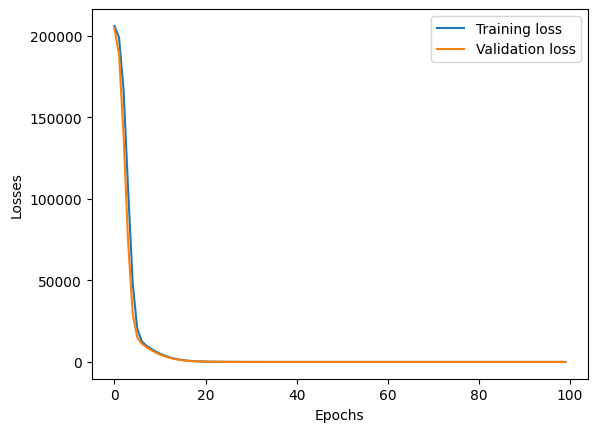

In [ ]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training_loss":train_losses,
    "validation_loss": val_losses
})

plt.plot(loss_df["Training_loss"] , label= "Training loss")
plt.plot(loss_df["validation_loss"] , label= "Validation loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [ ]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [ ]:
model.eval()
with torch.no_grad():
  train_perds = model(X_train_tensor)
  test_perds = model(X_test_tensor)

  train_mse_loss = criterion(train_perds, y_train_tensor)
  test_mse_loss = criterion(test_perds,y_test_tensor)

print("Training MSE : ",train_mse_loss.item())
print("Testing MSE : ",test_mse_loss.item())


Training MSE :  20.457714080810547
Testing MSE :  18.85350799560547


In [ ]:
from sklearn.metrics import r2_score
print(r2_score(y_test,test_perds))

0.9341118571306025


In [ ]:
predicted_df = pd.DataFrame(test_perds.numpy(), columns = ["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns = ["Actual Values"])
pd.concat([predicted_df,actual_df],axis=1)

,Predicted Values,Actual Values
0,435.754669,433.27
1,437.218628,438.16
2,461.097900,458.42
3,475.855164,480.82
4,435.583496,441.41
...,...,...
1909,451.493256,456.70
1910,432.044189,438.04
1911,467.704346,467.80
1912,431.463043,437.14
